# Quantile-Score Reviewer Experiments

The comparison methods are `TSCP_R`, `Unscaled`, `Empirical_copula`, and `CQHR`. The shifted-score section also includes `TSCP_GWC` because the current results suggest that `TSCP_R` and `TSCP_GWC` can produce identical regions under large shifts. That behavior is explicitly treated here as an investigation item, not as a resolved conclusion.

## Method Reminder

For each coordinate, raw CQR scores are signed:

$$
S_j(x, y) = \max\{ q_{low,j}(x) - y_j, y_j - q_{high,j}(x) \}
$$

`TSCP_R` and `TSCP_GWC` need nonnegative score-space inputs in this notebook. We therefore inspect two adaptations for TSCP-style methods:

- **Capped scores:** use $\max(S_j, 0)$. This only inflates base quantile intervals and never shrinks them.
- **Shifted scores:** use $S_j + C$, where `C` is calibration-independent and large enough to make scores nonnegative. After fitting the score region, subtract `C` from the coordinate adjustments before computing outcome-space lengths.

`Unscaled` and `Empirical_copula` are evaluated on raw signed CQR scores, because they can be interpreted directly as thresholding the raw CQR adjustments. `CQHR` is different again: it is the native quantile hyperrectangle method from Algorithm 2 of Sampson and Chan (2024), so its `score_transform` appears as `native` in the tables.

## Setup

In [18]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from utility.exps import run_cqr_synthetic_experiment
from utility.graphing_tools import (
    load_experiment_dataframes,
    save_experiment_dataframes,
    reviewer_summary_table,
    coordinate_length_table,
    plot_reviewer_metric_grid,
    plot_coordinate_length_profile,
    plot_metric_sweep,
)

pd.set_option('display.max_columns', 140)
pd.set_option('display.width', 180)

DATA_DIR = Path('reviewer_exps') / 'cqr'
DATA_DIR.mkdir(parents=True, exist_ok=True)

DIM = 3
N_FEATURES = 5
N_INFORMATIVE = 5
ALPHA = 0.1
TARGET_COVERAGE = 1 - ALPHA

CAPPED_METHODS = ['TSCP_R', 'Unscaled', 'Empirical_copula', 'CQHR']
CAPPED_DISPLAY_METHODS = ['TSCP (Ours)', 'Unscaled Max', 'Emp. Copula', 'CQHR']
SHIFTED_METHODS = ['TSCP_R', 'TSCP_GWC', 'Unscaled', 'Empirical_copula', 'CQHR']
SHIFTED_DISPLAY_METHODS = ['TSCP (Ours)', 'TSCP-GWC', 'Unscaled Max', 'Emp. Copula', 'CQHR']

print(f'Data folder: {DATA_DIR.resolve()}')

Data folder: E:\multi-target-scaling\reviewer_exps\cqr


## Run Controls

In [19]:
RUN_FULL_EXPERIMENTS = True
FORCE_RERUN = True

TRIALS = 100 if RUN_FULL_EXPERIMENTS else 2
N_TRAIN_POOL = 3000 if RUN_FULL_EXPERIMENTS else 160
N_CAL_FOCUS = 100 if RUN_FULL_EXPERIMENTS else 24
SAMPLE_LIST = [30, 50, 100, 200] if RUN_FULL_EXPERIMENTS else [20, 40]

# These are base interval miscoverage levels, not coverage levels.
# Example: base_interval_alpha=0.9 uses quantiles (0.45, 0.55), a very narrow base interval.
BASE_INTERVAL_ALPHA_LIST = [0.9, 0.7, 0.5, 0.3]
BASE_ALPHA_FOCUS = 0.5

DEFAULT_SHIFT = 100.0 * DIM
SHIFT_CONSTANTS = [DEFAULT_SHIFT, 100.0, 1000.0] if RUN_FULL_EXPERIMENTS else [DEFAULT_SHIFT, 1000.0]
SHIFTED_BASE_INTERVAL_ALPHA = BASE_ALPHA_FOCUS

QUANTILE_MODEL_PARAMS = {
    'n_estimators': 100 if RUN_FULL_EXPERIMENTS else 10,
    'max_depth': 5 if RUN_FULL_EXPERIMENTS else 2,
    'learning_rate': 0.05 if RUN_FULL_EXPERIMENTS else 0.08,
    'min_samples_leaf': 5,
}

print({
    'trials': TRIALS,
    'n_train_pool': N_TRAIN_POOL,
    'n_cal_focus': N_CAL_FOCUS,
    'sample_list': SAMPLE_LIST,
    'base_interval_alpha_list': BASE_INTERVAL_ALPHA_LIST,
    'shift_constants': SHIFT_CONSTANTS,
    'quantile_model_params': QUANTILE_MODEL_PARAMS,
})

{'trials': 100, 'n_train_pool': 3000, 'n_cal_focus': 100, 'sample_list': [30, 50, 100, 200], 'base_interval_alpha_list': [0.9, 0.7, 0.5, 0.3], 'shift_constants': [300.0, 100.0, 1000.0], 'quantile_model_params': {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.05, 'min_samples_leaf': 5}}


In [20]:
def result_to_tables(result):
    return {
        'trial': result.trial_results,
        'summary': result.summary_results,
        'coordinate_trial': result.coordinate_trial_results,
        'coordinate_summary': result.coordinate_summary_results,
    }


def combine_table_dicts(table_dicts):
    names = ['trial', 'summary', 'coordinate_trial', 'coordinate_summary']
    return {
        name: pd.concat([tables[name] for tables in table_dicts], ignore_index=True)
        for name in names
    }


def load_or_run(prefix, run_fn):
    required = ['trial', 'summary', 'coordinate_trial', 'coordinate_summary']
    if not FORCE_RERUN:
        loaded = load_experiment_dataframes(DATA_DIR, prefix, names=required)
        if all(name in loaded for name in required):
            print(f'Loaded saved tables for {prefix}')
            return loaded

    print(f'Running {prefix}...')
    tables = run_fn()
    paths = save_experiment_dataframes(tables, DATA_DIR, prefix)
    print('Saved:')
    for name, path in paths.items():
        print(f'  {name}: {path}')
    return tables


def cqr_runner_kwargs():
    return {
        'dim_list': [DIM],
        'alpha_list': [ALPHA],
        'noise_type': 'Gaussian',
        'trials': TRIALS,
        'n_train_pool': N_TRAIN_POOL,
        'n_features': N_FEATURES,
        'n_informative': N_INFORMATIVE,
        'quantile_model_params': QUANTILE_MODEL_PARAMS,
        'output_dir': None,
    }


def set_shift_for_display(tables, shift_constant):
    # Raw baselines and CQHR do not use the shift. We duplicate the shift label only so they can be plotted beside shifted TSCP methods.
    for df in tables.values():
        if 'method' in df.columns and 'shift_constant' in df.columns:
            mask = df['score_transform'].isin(['raw', 'native'])
            df.loc[mask, 'shift_constant'] = float(shift_constant)
    return tables

# Section 1: Capped Quantile Scores

This section uses `max(S_j, 0)` as the nonnegative score adaptation for `TSCP_R`. `Unscaled` and `Empirical_copula` use raw signed CQR scores. `CQHR` appears as the native quantile hyperrectangle baseline.

The central experiment varies `base_interval_alpha` over `[0.9, 0.7, 0.5, 0.3]`. These values are the base interval **alpha** values. Therefore, larger values mean narrower initial quantile intervals. This choice is intentional: if the base interval is already too wide, many capped scores become zero, especially at low calibration sizes.

## Experiment 1A: Base-Interval Alpha Sweep

**Purpose.** Check whether the capped-score story is sensitive to the base quantile interval width.

**Design.** Fix final conformal alpha at `0.1`, fix calibration size at `N_CAL_FOCUS`, and vary `base_interval_alpha`.

In [21]:
def run_capped_base_alpha_sweep():
    table_dicts = []
    for base_alpha in BASE_INTERVAL_ALPHA_LIST:
        result = run_cqr_synthetic_experiment(
            **cqr_runner_kwargs(),
            sample_list=[N_CAL_FOCUS],
            methods=CAPPED_METHODS,
            score_transform='capped',
            base_interval_alpha=base_alpha,
            experiment_name=f'cqr_capped_base_alpha_{base_alpha}',
        )
        table_dicts.append(result_to_tables(result))
    return combine_table_dicts(table_dicts)


capped_alpha_tables = load_or_run('capped_base_alpha_sweep', run_capped_base_alpha_sweep)
capped_alpha_summary = capped_alpha_tables['summary']
capped_alpha_coordinate_summary = capped_alpha_tables['coordinate_summary']

display(reviewer_summary_table(
    capped_alpha_summary,
    group_cols=['base_interval_alpha', 'score_transform'],
    methods=CAPPED_DISPLAY_METHODS,
    target_coverage=TARGET_COVERAGE,
))

Running capped_base_alpha_sweep...
Saved:
  trial: reviewer_exps\cqr\capped_base_alpha_sweep_trial.csv
  summary: reviewer_exps\cqr\capped_base_alpha_sweep_summary.csv
  coordinate_trial: reviewer_exps\cqr\capped_base_alpha_sweep_coordinate_trial.csv
  coordinate_summary: reviewer_exps\cqr\capped_base_alpha_sweep_coordinate_summary.csv


,base_interval_alpha,score_transform,method,n_trials,coverage,volume,runtime,meets_target
0,0.3,capped,TSCP (Ours),100,0.892(0.034),4.038e+03(8.877e+02),0.001,False
1,0.3,native,CQHR,100,0.901(0.028),7.236e+03(2.366e+03),0.000,True
2,0.3,raw,Unscaled Max,100,0.894(0.033),4.228e+03(8.965e+02),0.000,False
3,0.3,raw,Emp. Copula,100,0.873(0.037),3.609e+03(7.602e+02),0.001,False
4,0.5,capped,TSCP (Ours),100,0.892(0.037),2.839e+03(7.230e+02),0.001,False
5,0.5,native,CQHR,100,0.906(0.032),2.592e+06(1.372e+07),0.000,True
6,0.5,raw,Unscaled Max,100,0.893(0.032),3.212e+03(7.468e+02),0.000,False
7,0.5,raw,Emp. Copula,100,0.872(0.037),2.480e+03(5.589e+02),0.001,False
8,0.7,capped,TSCP (Ours),100,0.891(0.032),2.443e+03(6.744e+02),0.001,False
9,0.7,native,CQHR,100,0.904(0.030),8.455e+09(6.057e+10),0.000,True


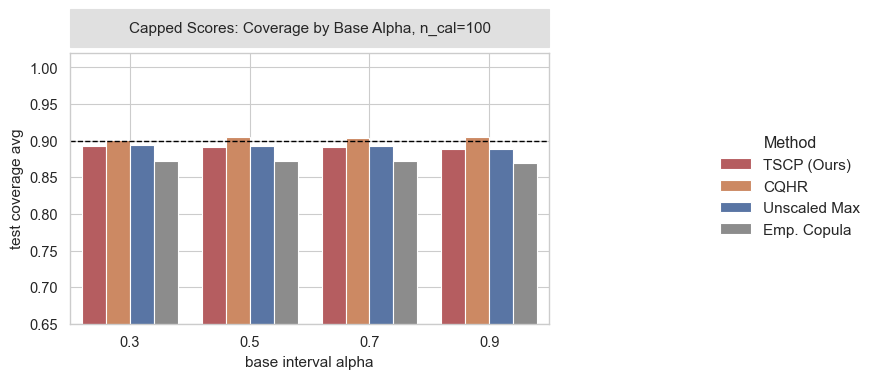

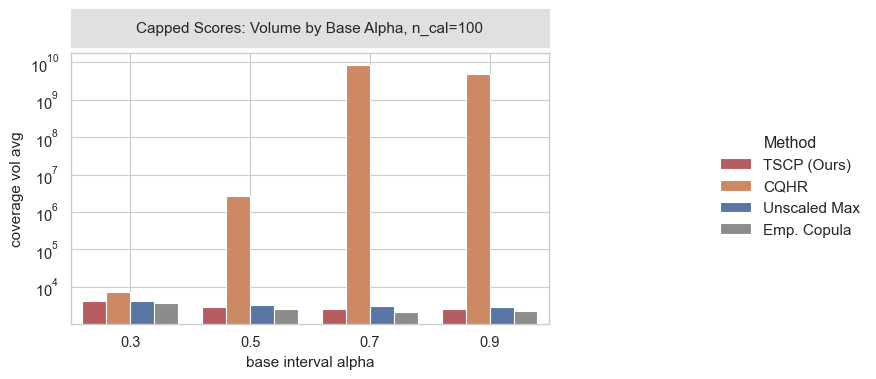

In [22]:
fig, ax = plot_metric_sweep(
    capped_alpha_summary,
    x='base_interval_alpha',
    metric='test_coverage_avg',
    methods=CAPPED_DISPLAY_METHODS,
    target_coverage=TARGET_COVERAGE,
    log_y=False,
    plot_kind='bar',
    title=f'Capped Scores: Coverage by Base Alpha, n_cal={N_CAL_FOCUS}',
)
plt.show()

fig, ax = plot_metric_sweep(
    capped_alpha_summary,
    x='base_interval_alpha',
    metric='coverage_vol_avg',
    methods=CAPPED_DISPLAY_METHODS,
    plot_kind='bar',
    title=f'Capped Scores: Volume by Base Alpha, n_cal={N_CAL_FOCUS}',
)
plt.show()

## Experiment 1B: Coordinate-Wise Lengths

**Purpose.** Show the coordinate-level interval lengths for one representative base alpha. This is the CQR analogue of the coordinate-wise absolute-residual experiment.

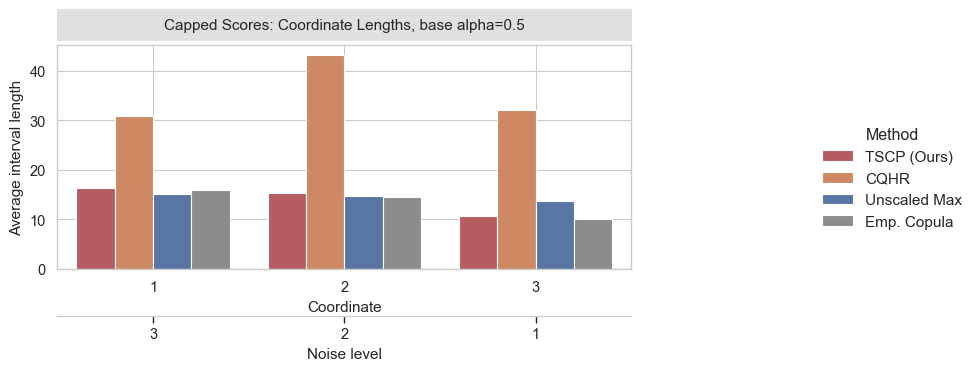

method_display,n_cal,score_transform,base_interval_alpha,shift_constant,coordinate,noise_level,TSCP (Ours),CQHR,Unscaled Max,Emp. Copula
0,100,capped,0.5,0.0,1,3.0,16.37,,,
1,100,capped,0.5,0.0,2,2.0,15.22,,,
2,100,capped,0.5,0.0,3,1.0,10.68,,,
3,100,native,0.5,0.0,1,3.0,,30.78,,
4,100,native,0.5,0.0,2,2.0,,43.04,,
5,100,native,0.5,0.0,3,1.0,,32.00,,
6,100,raw,0.5,0.0,1,3.0,,,14.99,15.80
7,100,raw,0.5,0.0,2,2.0,,,14.66,14.57
8,100,raw,0.5,0.0,3,1.0,,,13.71,10.12


{'capped_coordinate_length_table': WindowsPath('reviewer_exps/cqr/capped_base_alpha_sweep_capped_coordinate_length_table.csv')}

In [23]:
coord_df = capped_alpha_coordinate_summary[
    capped_alpha_coordinate_summary['base_interval_alpha'].eq(BASE_ALPHA_FOCUS)
].copy()

fig, ax = plot_coordinate_length_profile(
    coord_df,
    methods=CAPPED_DISPLAY_METHODS,
    noise_levels=np.arange(DIM, 0, -1),
    coordinate_scale=1.0,
    title=f'Capped Scores: Coordinate Lengths, base alpha={BASE_ALPHA_FOCUS}',
)
plt.show()

coord_table = coordinate_length_table(
    coord_df,
    methods=CAPPED_DISPLAY_METHODS,
    noise_levels=np.arange(DIM, 0, -1),
    coordinate_scale=1.0,
    value_format=lambda value: f'{value:.2f}',
)
display(coord_table)
save_experiment_dataframes({'capped_coordinate_length_table': coord_table}, DATA_DIR, 'capped_base_alpha_sweep')

## Experiment 1C: Sample-Size Sanity Check

**Purpose.** This is the only capped-score line-plot experiment because the x-axis is the number of calibration samples. It checks whether conclusions at the selected base alpha are stable as calibration size grows.

In [24]:
def run_capped_sample_size_check():
    result = run_cqr_synthetic_experiment(
        **cqr_runner_kwargs(),
        sample_list=SAMPLE_LIST,
        methods=CAPPED_METHODS,
        score_transform='capped',
        base_interval_alpha=BASE_ALPHA_FOCUS,
        experiment_name='cqr_capped_sample_size_check',
    )
    return result_to_tables(result)


capped_sample_tables = load_or_run('capped_sample_size_check', run_capped_sample_size_check)
capped_sample_summary = capped_sample_tables['summary']

display(reviewer_summary_table(
    capped_sample_summary,
    group_cols=['n_cal', 'base_interval_alpha', 'score_transform'],
    methods=CAPPED_DISPLAY_METHODS,
    target_coverage=TARGET_COVERAGE,
))

Running capped_sample_size_check...
Saved:
  trial: reviewer_exps\cqr\capped_sample_size_check_trial.csv
  summary: reviewer_exps\cqr\capped_sample_size_check_summary.csv
  coordinate_trial: reviewer_exps\cqr\capped_sample_size_check_coordinate_trial.csv
  coordinate_summary: reviewer_exps\cqr\capped_sample_size_check_coordinate_summary.csv


,n_cal,base_interval_alpha,score_transform,method,n_trials,coverage,volume,runtime,meets_target
0,30,0.5,capped,TSCP (Ours),100,0.895(0.063),3.520e+03(1.748e+03),0.001,False
1,30,0.5,native,CQHR,100,0.900(0.057),1.446e+07(5.554e+07),0.000,True
2,30,0.5,raw,Unscaled Max,100,0.890(0.064),3.563e+03(1.623e+03),0.000,False
3,30,0.5,raw,Emp. Copula,100,0.817(0.076),2.098e+03(8.617e+02),0.000,False
4,50,0.5,capped,TSCP (Ours),100,0.905(0.040),3.366e+03(1.457e+03),0.001,True
5,50,0.5,native,CQHR,100,0.910(0.038),6.312e+07(4.483e+08),0.000,True
6,50,0.5,raw,Unscaled Max,100,0.893(0.044),3.412e+03(1.460e+03),0.000,False
7,50,0.5,raw,Emp. Copula,100,0.869(0.051),2.630e+03(9.819e+02),0.001,False
8,100,0.5,capped,TSCP (Ours),100,0.892(0.037),2.839e+03(7.230e+02),0.001,False
9,100,0.5,native,CQHR,100,0.906(0.032),2.592e+06(1.372e+07),0.000,True


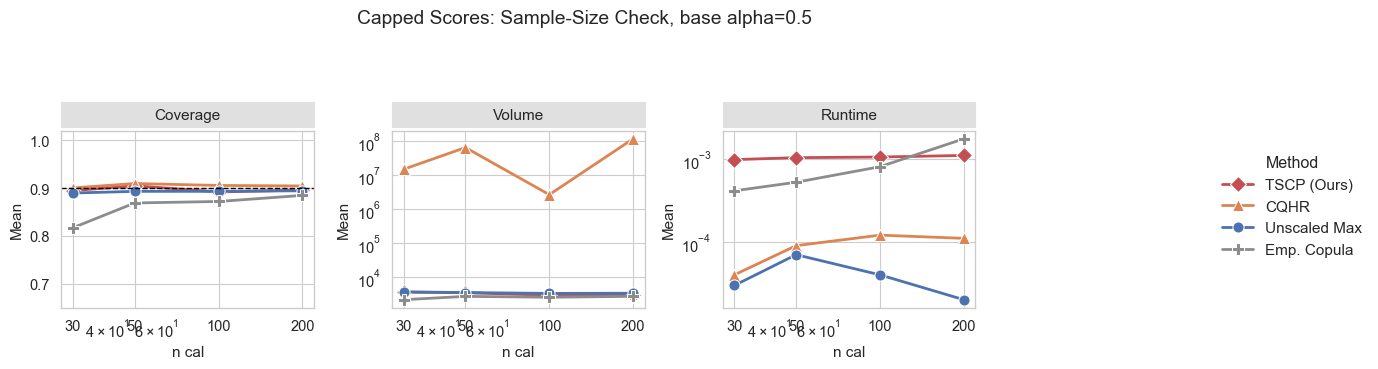

In [25]:
fig, axes = plot_reviewer_metric_grid(
    capped_sample_summary,
    x='n_cal',
    methods=CAPPED_DISPLAY_METHODS,
    target_coverage=TARGET_COVERAGE,
    log_x=True,
    title=f'Capped Scores: Sample-Size Check, base alpha={BASE_ALPHA_FOCUS}',
)
plt.show()

# Section 2: Shifted Quantile Scores

This section uses `S_j + C` for `TSCP_R` and `TSCP_GWC`, then subtracts `C` from the final coordinate adjustments before computing outcome-space lengths. `Unscaled` and `Empirical_copula` continue to use raw signed CQR scores, while `CQHR` remains native.

The key diagnostic is the comparison between `TSCP_R` and `TSCP_GWC`. In prior exploratory runs, these two methods sometimes produced identical regions under shifted scores. My current interpretation is that a large shift can dominate the score geometry and cause the local refinement in `TSCP_R` to collapse to the global-worst-case boundary. This notebook documents that behavior while I continue investigating whether it is intrinsic to the shifted adaptation or indicates an implementation issue.

## Experiment 2A: Shift-Constant Sensitivity

**Purpose.** Check how coverage, volume, and coordinate lengths change as the shift constant increases. `CQHR` is shown as a native quantile baseline and does not use the shift itself.

In [26]:
def run_shifted_sensitivity():
    table_dicts = []
    for shift in SHIFT_CONSTANTS:
        result = run_cqr_synthetic_experiment(
            **cqr_runner_kwargs(),
            sample_list=[N_CAL_FOCUS],
            methods=SHIFTED_METHODS,
            score_transform='shifted',
            shift_constant=shift,
            base_interval_alpha=SHIFTED_BASE_INTERVAL_ALPHA,
            experiment_name=f'cqr_shifted_C_{shift}',
        )
        tables = set_shift_for_display(result_to_tables(result), shift)
        table_dicts.append(tables)
    return combine_table_dicts(table_dicts)


shifted_tables = load_or_run('shifted_sensitivity', run_shifted_sensitivity)
shifted_summary = shifted_tables['summary']
shifted_coordinate_summary = shifted_tables['coordinate_summary']

display(reviewer_summary_table(
    shifted_summary,
    group_cols=['shift_constant', 'base_interval_alpha', 'score_transform'],
    methods=SHIFTED_DISPLAY_METHODS,
    target_coverage=TARGET_COVERAGE,
))

Running shifted_sensitivity...
Saved:
  trial: reviewer_exps\cqr\shifted_sensitivity_trial.csv
  summary: reviewer_exps\cqr\shifted_sensitivity_summary.csv
  coordinate_trial: reviewer_exps\cqr\shifted_sensitivity_coordinate_trial.csv
  coordinate_summary: reviewer_exps\cqr\shifted_sensitivity_coordinate_summary.csv


,shift_constant,base_interval_alpha,score_transform,method,n_trials,coverage,volume,runtime,meets_target
0,100.0,0.5,native,CQHR,100,0.906(0.032),2.592e+06(1.372e+07),0.000,True
1,100.0,0.5,raw,Unscaled Max,100,0.893(0.032),3.212e+03(7.468e+02),0.000,False
2,100.0,0.5,raw,Emp. Copula,100,0.872(0.037),2.480e+03(5.589e+02),0.001,False
3,100.0,0.5,shifted,TSCP (Ours),100,0.894(0.037),2.856e+03(7.284e+02),0.001,False
4,100.0,0.5,shifted,TSCP-GWC,100,0.894(0.037),2.856e+03(7.284e+02),0.000,False
5,300.0,0.5,native,CQHR,100,0.906(0.032),2.592e+06(1.372e+07),0.000,True
6,300.0,0.5,raw,Unscaled Max,100,0.893(0.032),3.212e+03(7.468e+02),0.000,False
7,300.0,0.5,raw,Emp. Copula,100,0.872(0.037),2.480e+03(5.589e+02),0.001,False
8,300.0,0.5,shifted,TSCP (Ours),100,0.894(0.037),2.856e+03(7.284e+02),0.001,False
9,300.0,0.5,shifted,TSCP-GWC,100,0.894(0.037),2.856e+03(7.284e+02),0.000,False


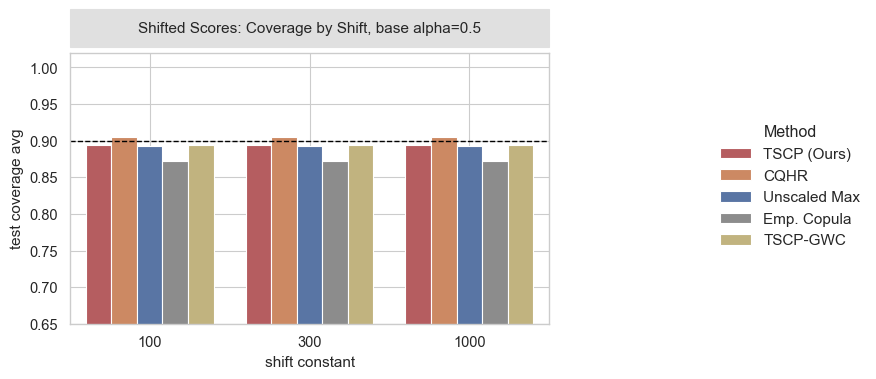

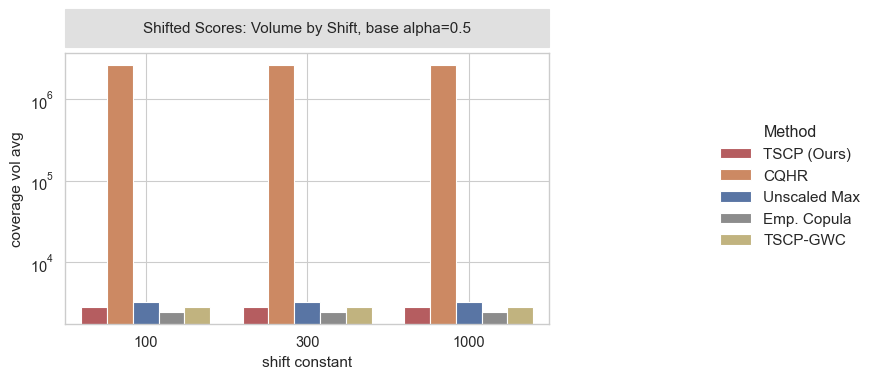

In [27]:
fig, ax = plot_metric_sweep(
    shifted_summary,
    x='shift_constant',
    metric='test_coverage_avg',
    methods=SHIFTED_DISPLAY_METHODS,
    target_coverage=TARGET_COVERAGE,
    log_y=False,
    plot_kind='bar',
    title=f'Shifted Scores: Coverage by Shift, base alpha={SHIFTED_BASE_INTERVAL_ALPHA}',
)
plt.show()

fig, ax = plot_metric_sweep(
    shifted_summary,
    x='shift_constant',
    metric='coverage_vol_avg',
    methods=SHIFTED_DISPLAY_METHODS,
    plot_kind='bar',
    title=f'Shifted Scores: Volume by Shift, base alpha={SHIFTED_BASE_INTERVAL_ALPHA}',
)
plt.show()

## Experiment 2B: TSCP_R vs TSCP_GWC Diagnostic

**Purpose.** Quantify how close `TSCP_R` and `TSCP_GWC` are under shifted scores. The table below reports maximum absolute differences in coordinate lengths and coordinate adjustments. Values close to zero indicate that the two regions are numerically identical in this experiment.

In [28]:
def tscp_r_gwc_diagnostic(summary_df, coordinate_summary_df):
    coord = coordinate_summary_df[
        coordinate_summary_df['method'].isin(['TSCP_R', 'TSCP_GWC'])
        & coordinate_summary_df['score_transform'].eq('shifted')
    ].copy()
    left = coord[coord['method'].eq('TSCP_R')]
    right = coord[coord['method'].eq('TSCP_GWC')]
    merge_cols = ['alpha', 'n_dim', 'n_cal', 'noise_type', 'base_interval_alpha', 'shift_constant', 'coordinate']
    merged = left.merge(right, on=merge_cols, suffixes=('_r', '_gwc'))
    merged['abs_coordinate_length_diff'] = (
        merged['coordinate_length_avg_r'] - merged['coordinate_length_avg_gwc']
    ).abs()
    merged['abs_coordinate_adjustment_diff'] = (
        merged['coordinate_adjustment_avg_r'] - merged['coordinate_adjustment_avg_gwc']
    ).abs()

    coord_diag = merged.groupby(
        ['alpha', 'n_dim', 'n_cal', 'base_interval_alpha', 'shift_constant'],
        as_index=False,
    ).agg(
        max_abs_coordinate_length_diff=('abs_coordinate_length_diff', 'max'),
        max_abs_coordinate_adjustment_diff=('abs_coordinate_adjustment_diff', 'max'),
    )

    summ = summary_df[
        summary_df['method'].isin(['TSCP_R', 'TSCP_GWC'])
        & summary_df['score_transform'].eq('shifted')
    ].copy()
    wide = summ.pivot_table(
        index=['alpha', 'n_dim', 'n_cal', 'base_interval_alpha', 'shift_constant'],
        columns='method',
        values=['coverage_vol_avg', 'test_coverage_avg'],
        aggfunc='mean',
    )
    wide.columns = [f'{metric}_{method}' for metric, method in wide.columns]
    wide = wide.reset_index()
    wide['abs_volume_diff'] = (wide['coverage_vol_avg_TSCP_R'] - wide['coverage_vol_avg_TSCP_GWC']).abs()
    wide['abs_coverage_diff'] = (wide['test_coverage_avg_TSCP_R'] - wide['test_coverage_avg_TSCP_GWC']).abs()
    return coord_diag.merge(wide, on=['alpha', 'n_dim', 'n_cal', 'base_interval_alpha', 'shift_constant'])


diagnostic_table = tscp_r_gwc_diagnostic(shifted_summary, shifted_coordinate_summary)
display(diagnostic_table)
save_experiment_dataframes({'tscp_r_vs_gwc_diagnostic': diagnostic_table}, DATA_DIR, 'shifted_sensitivity')

,alpha,n_dim,n_cal,base_interval_alpha,shift_constant,max_abs_coordinate_length_diff,max_abs_coordinate_adjustment_diff,coverage_vol_avg_TSCP_GWC,coverage_vol_avg_TSCP_R,test_coverage_avg_TSCP_GWC,test_coverage_avg_TSCP_R,abs_volume_diff,abs_coverage_diff
0,0.1,3,100,0.5,100.0,0.0,0.0,2856.183858,2856.183858,0.89365,0.89365,0.0,0.0
1,0.1,3,100,0.5,300.0,0.0,0.0,2856.183858,2856.183858,0.89365,0.89365,0.0,0.0
2,0.1,3,100,0.5,1000.0,0.0,0.0,2856.183858,2856.183858,0.89365,0.89365,0.0,0.0


{'tscp_r_vs_gwc_diagnostic': WindowsPath('reviewer_exps/cqr/shifted_sensitivity_tscp_r_vs_gwc_diagnostic.csv')}

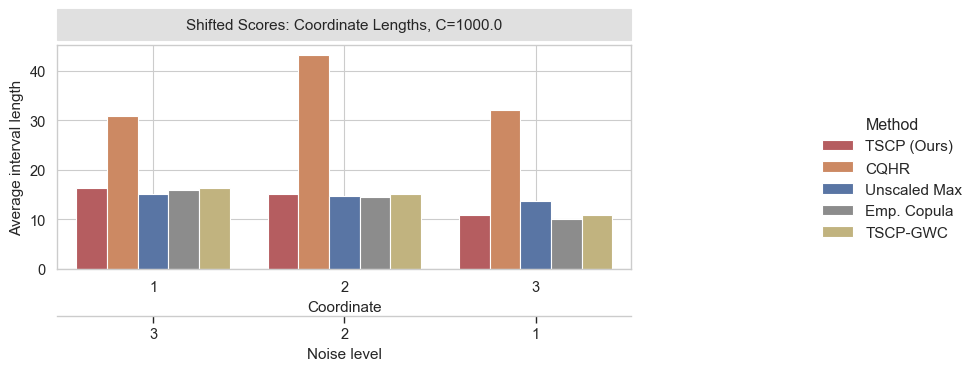

method_display,n_cal,score_transform,base_interval_alpha,shift_constant,coordinate,noise_level,TSCP (Ours),CQHR,Unscaled Max,Emp. Copula,TSCP-GWC
0,100,native,0.5,1000.0,1,3.0,,30.78,,,
1,100,native,0.5,1000.0,2,2.0,,43.04,,,
2,100,native,0.5,1000.0,3,1.0,,32.00,,,
3,100,raw,0.5,1000.0,1,3.0,,,14.99,15.80,
4,100,raw,0.5,1000.0,2,2.0,,,14.66,14.57,
5,100,raw,0.5,1000.0,3,1.0,,,13.71,10.12,
6,100,shifted,0.5,1000.0,1,3.0,16.33,,,,16.33
7,100,shifted,0.5,1000.0,2,2.0,15.12,,,,15.12
8,100,shifted,0.5,1000.0,3,1.0,10.80,,,,10.80


{'shifted_coordinate_length_table': WindowsPath('reviewer_exps/cqr/shifted_sensitivity_shifted_coordinate_length_table.csv')}

In [29]:
shift_to_show = max(SHIFT_CONSTANTS)
shift_coord_df = shifted_coordinate_summary[
    shifted_coordinate_summary['shift_constant'].eq(shift_to_show)
].copy()

fig, ax = plot_coordinate_length_profile(
    shift_coord_df,
    methods=SHIFTED_DISPLAY_METHODS,
    noise_levels=np.arange(DIM, 0, -1),
    coordinate_scale=1.0,
    title=f'Shifted Scores: Coordinate Lengths, C={shift_to_show}',
)
plt.show()

shift_coord_table = coordinate_length_table(
    shift_coord_df,
    methods=SHIFTED_DISPLAY_METHODS,
    noise_levels=np.arange(DIM, 0, -1),
    coordinate_scale=1.0,
    value_format=lambda value: f'{value:.2f}',
)
display(shift_coord_table)
save_experiment_dataframes({'shifted_coordinate_length_table': shift_coord_table}, DATA_DIR, 'shifted_sensitivity')

## Working Notes 

- Capped scores are straightforward and stable to explain for TSCP_R: they produce nonnegative scores by truncating negative CQR residuals at zero, but they only allow interval inflation.
- The `base_interval_alpha` sweep is intentionally using large alpha values such as `0.9`; these are narrow base intervals, which reduces the number of capped zero scores in small calibration regimes.
- Unscaled and Empirical Copula use raw signed CQR scores here because negative adjustments are meaningful in CQR outcome space.
- CQHR is the native quantile hyperrectangle benchmark from Sampson and Chan. It is not a capped or shifted score-space method.
- Shifted scores are still under investigation. The key question is why `TSCP_R` and `TSCP_GWC` can become numerically identical after a large constant shift. The diagnostic table is meant to make that issue concrete.

## Export Index

The files below are the reusable cached results. Move this folder with the notebook to inspect results without rerunning the experiments.

In [30]:
export_index = pd.DataFrame({
    'file': [path.name for path in sorted(DATA_DIR.glob('*.csv'))],
    'path': [str(path.resolve()) for path in sorted(DATA_DIR.glob('*.csv'))],
})
display(export_index)

,file,path
0,capped_base_alpha_sweep_capped_coordinate_leng...,E:\multi-target-scaling\reviewer_exps\cqr\capp...
1,capped_base_alpha_sweep_coordinate_summary.csv,E:\multi-target-scaling\reviewer_exps\cqr\capp...
2,capped_base_alpha_sweep_coordinate_trial.csv,E:\multi-target-scaling\reviewer_exps\cqr\capp...
3,capped_base_alpha_sweep_summary.csv,E:\multi-target-scaling\reviewer_exps\cqr\capp...
4,capped_base_alpha_sweep_trial.csv,E:\multi-target-scaling\reviewer_exps\cqr\capp...
5,capped_sample_size_check_coordinate_summary.csv,E:\multi-target-scaling\reviewer_exps\cqr\capp...
6,capped_sample_size_check_coordinate_trial.csv,E:\multi-target-scaling\reviewer_exps\cqr\capp...
7,capped_sample_size_check_summary.csv,E:\multi-target-scaling\reviewer_exps\cqr\capp...
8,capped_sample_size_check_trial.csv,E:\multi-target-scaling\reviewer_exps\cqr\capp...
9,shifted_sensitivity_coordinate_summary.csv,E:\multi-target-scaling\reviewer_exps\cqr\shif...
